# Assignment 10

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

---

#### ``Objectives``
1. Implement a CNN to detect diabetic retinopathy (DR) from retina images taken using fundus photography under a variety of imaging conditions.
2. Improve generalization performance and reduce overfitting using **image transformation** and **data augmentation** techniques.

#### ``Motivation``

Diabetic retinopathy (DR) is an eye condition that  affects blood vessels in the retina. It can cause vision loss and blindness in people who have diabetes. Screening for DR allows earlier and more effective treatment options for millions of people.

#### ``Data``

In this assignment you will use a small dataset of retina images (`Download` links: [images](https://drive.google.com/drive/folders/1sdfUC64Un1iwuiHEehcbijxB54OhU_nd?usp=sharing) and [labels](https://drive.google.com/drive/folders/1MOlSJBZg7L1HtG5vHPt77ighRvQaGfDg?usp=sharing)). You will **build** and **train** a **CNN model** to predict whether or not to refer a patient for DR treatment using binarized severity of DR in patients: no referral if {No DR, mild} and referral if {moderate, severe, and proliferate DR}.


<u>Note</u>: the original dataset is hosted by Kaggle [[Source]](https://www.kaggle.com/c/aptos2019-blindness-detection/).

Import the necessary libraries and make sure to replace IMAGE_PATH and LABEL_PATH with the path to the directories where you saved the data.

---
### Step 1: Import libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

w207_assignments_path = '/content/drive/MyDrive/Colab Notebooks/w207/w207 Assignments'
os.chdir(w207_assignments_path)
os.getcwd()

'/content/drive/MyDrive/Colab Notebooks/w207/w207 Assignments'

In [59]:
# standard
import pandas as pd
import numpy as np
import random
import os

# tf and keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from keras import models
from keras import layers

# sklearn
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# plots
import seaborn as sns
import matplotlib.pyplot as plt

random.seed(2)
%matplotlib inline

# FILL IN CODE HERE #
IMAGE_PATH = '../w207 Cornelia Modules/data/DiabeticRetinopathy/images/' # replace with your path
LABEL_PATH = '../w207 Cornelia Modules/data/DiabeticRetinopathy/labels/' # replace with your path

At this point, you may ask yourself what the best model that fits this data is. First, you will want to read through the data description in Kaggle (see the link to the original dataset above). Understanding what you are working with challenges you to write preprocessing code that uncovers your data's most helpful information.

---
#### <span style="color:chocolate"> Exercise 1 (10 points) </span>

Read the data description from Kaggle and list (a) the source of images and (b) the labeling procedure.

*Written answer*:

(a) The source of the images comes from retina images taken using fundus photography under a variety of imaging conditions, and they were gathered from a variety of clinics using multiple different cameras over an extended period of time.

Many of these images were likely collected by technicians in rural areas to help identify diabetic retinopathy, and the main sponsor of this data was the Aravind Eye Hospital in India.

(b) The labeling procedure involves a clinician rating each image for the severity of diabetic retinopathy on a scale of 0 to 4:
- 0 - No DR
- 1 - Mild
- 2 - Moderate
- 3 - Severe
- 4 - Proliferative DR

---
### Step 2: Data ingestion

Let's load the 2D images and their corresponding labels.

``labels``

In [4]:
labels = pd.read_csv(
    LABEL_PATH + 'labels.csv'
)

print('Shape of labels:', labels.shape)
print('Unique diagnosis codes:', np.sort(labels.diagnosis.unique()))
labels.head()

Shape of labels: (200, 2)
Unique diagnosis codes: [0 1 2 3 4]


,id_code,diagnosis
0,000c1434d8d7,2
1,0024cdab0c1e,1
2,0083ee8054ee,4
3,00a8624548a9,2
4,00b74780d31d,2


There are 200 training images corrresponding to 5 different diabetic retinopathy (DR) diagnosis codes:

* No DR (0)
* mild (1)
* moderate (2)
* severe (3)
* proliferate DR (4)


``images``

In [5]:
images = []

for idx, img in enumerate(os.listdir(IMAGE_PATH)):
    img = load_img(
    IMAGE_PATH + img)
    images.append(img)

---
### Step 3: Exploratory Data Analysis (EDA)

#### <span style="color:chocolate"> Exercise 2 (10 points) </span>

Plot a histogram for the five classes of DR. Are the classes balanced?


Note: It's acceptable to plot the distribution of classes before splitting your data into training, validation, and test sets. Doing so does not compromise the "blindness" of the test data. Why?

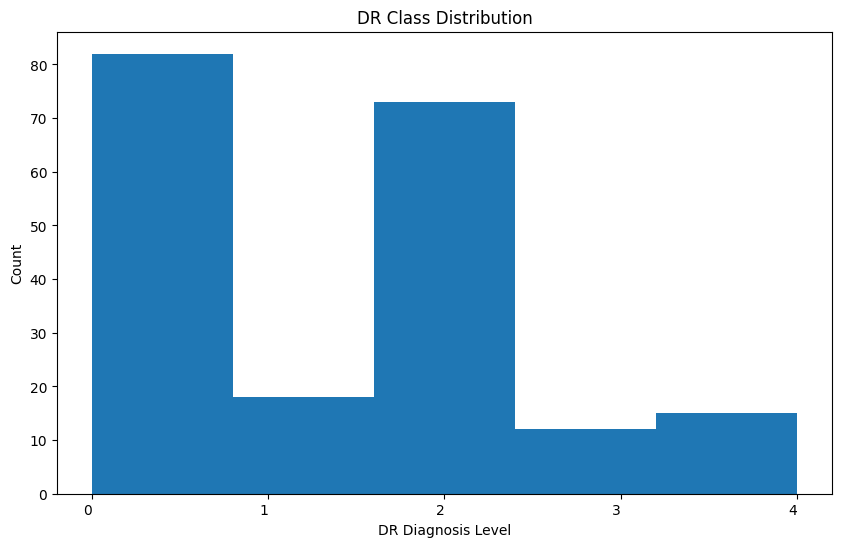

In [33]:
# YOUR CODE HERE

# Plotting a histogram of the DR labels class distribution
plt.figure(figsize=(10, 6))
plt.hist(labels['diagnosis'], align='mid', bins=5)
plt.xlabel("DR Diagnosis Level")
plt.xticks(ticks=[0,1,2,3,4],rotation=0, ha='right')
plt.ylabel("Count")
plt.title("DR Class Distribution")

plt.show()

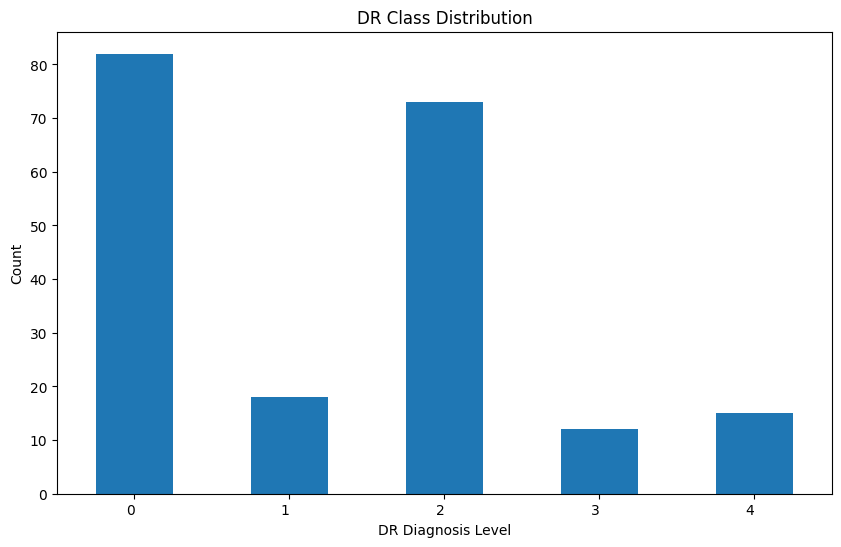

In [41]:
# Plotting a bar graph instead for easier viewing

# Getting DR class labels as a value_counts df (for easier plotting)
labels_counts = labels['diagnosis'].value_counts().sort_index()

# Plotting the DR labels class distribution
plt.figure(figsize=(10, 6))
labels_counts.plot(kind='bar')
plt.xlabel("DR Diagnosis Level")
plt.xticks(rotation=0, ha='right')
plt.ylabel("Count")
plt.title("DR Class Distribution")

plt.show()

Comment on class balance: The classes are very imbalanced, with a diagnosis of 0 or 2 being significantly more frequent than the others. This could create noticeable generalization problems during inference, as the model would perform likely better for the majority classes.

Plotting the distribution of classes before splitting the data does not compromise the "blindness" of the test data because it does not expose specific test samples. All you're doing with the plotting is seeing aggregate statistics of the whole dataset, so you're not leaking any information. Furthermore, if your dataset is very imbalanced, plotting the class distribution can help you sample your data properly so that the training, validation, and test datasets all have the same class proportions (and therefore hopefully making your model more generalizable).

#### <span style="color:chocolate"> Exercise 3 (10 points) </span>

Print 8 images from the data. What can you say about the size, focus/orientation of these images?

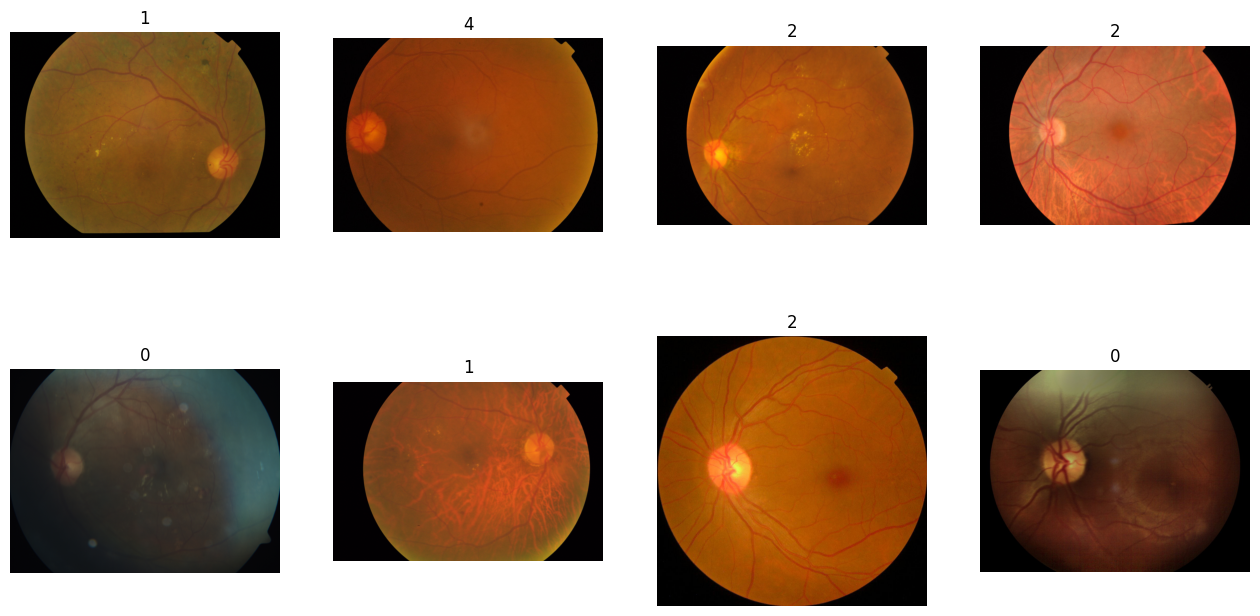

In [124]:
# FILL IN CODE HERE #

# Displaying the first 8 images
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
count = 0
for i in range(2):
  for j in range(4):
    count += 1
    axs[i][j].imshow(images[count])
    axs[i][j].set_title(labels['diagnosis'][count])
    axs[i][j].axis('off')

Comment on the size, focus/orientation of the 8 images: The size, focus, and orientation of the first 8 images are all very different. In terms of the size, while being roughly of similar shapes, some of the images are more rectangular, while some are square-shaped (though even for the rectangular images, their sizes are quite different). In terms of the focus, some of the images (e.g., image at index position [1, 2]) are quite sharp, whereas others (e.g., images at index positions [1, 0] and [1, 3]) are much more blurry and difficult to make out. Furthermore, the latter images also have a lower brightness than some of the other images. Lastly, the images seem to be oriented differently. Notably, the optic disc (bright part of the eye) seems to be oriented in both the left and right directions, indicating the pictures were taken of both the left and right eyes.

Overall, all these variations will likely give our model a harder time training. However, it gives the benefit of making our model (hopefully) more generalizable to unseen images, with their own unique sizes, focus, and orientation.

---
### Step 4: Data preprocessing

First, we will correct for class imbalance. Note that imbalanced data is common in healthcare, and it happens because some diseases are rare. The presence of imbalanced data hampers the detection of rare events as most classification methods implicitly assume a similar occurrence of classes and are designed to maximize the overall classification accuracy.

We will correct for class imbalance in two ways:

  * First, we will binarize the DR diagnosis as follows:
     - 'no refer' are {No DR, mild}
     - 'refer' are {Moderate, Severe, Proliferate}


  * Second, we'll only take 80 random samples from the 'no refer' class and 80 from the 'refer' class.

It is a crude method to deal with imbalanced data, but it will be good enough for this homework.

In [56]:
np.random.seed(1234)

no_refer = labels[labels.diagnosis.isin((0,1))]
refer = labels[labels.diagnosis.isin((2,3,4))]

# randomly draw 80 images from each classes
temp_no_refer = list(np.random.choice(
    no_refer.id_code,
    size=80,
    replace=False
))

temp_refer = list(np.random.choice(
    refer.id_code,
    size=80,
    replace=False
))

Next, we will use the ``preprocess_data_part1()`` function defined below to generate lists of images and labels (images_mini and y_mini) based on the values in the temp_no_refer and temp_refer lists. Note that the size of the image is set to (224, 224).

In [57]:
def preprocess_data_part1(IMAGE_PATH, LABEL_PATH, temp_no_refer, temp_refer):
    """ Generate lists of images and labelsbased on temp_no_refer and temp_refer lists

    Params:
    -------
    IMAGE_PATH (str): path to directory with images.
    LABEL_PATH (str): path to directory with labels.
    temp_no_refer (str): list of labels for the no refer category
    temp_refer (str): list of labels for the refer category

    Returns:
    --------
    images_mini  (np.ndarray): Images of shape (N, 224, 224, 3)
    y_mini (np.ndarray): Labels of shape (N,)
    """
    y_mini = []
    images_mini = []

    # create lists of images and labels `images_mini` and `y_mini`
    # based on temp_no_refer and temp_refer selections
    for idx, img in enumerate(os.listdir(IMAGE_PATH)):
        # read labels
        if img.split('.')[0] in temp_no_refer:
                y_mini.append(0)
        elif img.split('.')[0] in temp_refer:
                y_mini.append(1)
        else:
            continue


        # read image
        img = load_img(
            IMAGE_PATH + img,
            target_size=(224, 224)
        )

        # transform image to array
        img = img_to_array(img)

        # append to images
        images_mini.append(img)

    # stack images and trasnform to array
    images_mini = np.stack(images_mini)
    y_mini = np.array(y_mini).flatten()

    return images_mini, y_mini

In [58]:
# generate images and labels based on preprocess_data_part1() function
images_mini, y_mini = preprocess_data_part1(
    IMAGE_PATH, LABEL_PATH, temp_no_refer, temp_refer
)

print(f"images_mini shape {images_mini.shape}")
print(f"y_mini shape {y_mini.shape}")

images_mini shape (160, 224, 224, 3)
y_mini shape (160,)


#### <span style="color:chocolate"> Exercise 4 (20 points) </span>

Create train, validation, and test data. Implement the `preprocess_data_part2()` function according to the following guidelines:

1. shuffle images and labels before splitting the data

2. use a (0.6,0.2,0.2)train/validation/test set split

3. perform image transformation and augmentation, as follows:
    * Applied on training set only:
         - create additional copies (augmentations) of the training images by flipping left right each image (Hint: use the method available in the tf.image module).
         - concatenate the augmented images to the original training images. Note that the train set should be double in size after data augmentation, i.e., 192 images and labels.
    * Applied on training, validation, and test sets:
        - rescale images by dividing each pixel by 255.0

Reason for doing image augmentation: The quantity and diversity of data gathered significantly impact the results of a CNN model. One can use augmentations to artificially inflate the training dataset by warping the original data so that their label does not change. These augmentations can significantly improve learning results without collecting new data.

In [64]:
def preprocess_data_part2(images, labels, splits):
    """ Split data into train, validation and test sets; apply transformaions and augmentations

    Params:
    -------
    images  (np.ndarray): Images of shape (N, 224, 224, 3)
    labels (np.ndarray): Labels of shape (N,)
    splits (tuple): 3 values summing to 1 defining split of train, validation and test sets

    Returns:
    --------
    X_train (np.ndarray): Train images of shape (N_train, 224, 224, 3)
    y_train (np.ndarray): Train labels of shape (N_train,)
    X_val (np.ndarray): Val images of shape (N_val, 224, 224, 3)
    y_val (np.ndarray): Val labels of shape (N_val,)
    X_test (np.ndarray): Test images of shape (N_test, 224, 224, 3)
    y_test (np.ndarray): Test labels of shape (N_test,)

    """

    # NOTE: Each time you run this cell, you'll re-shuffle the data. The ordering will be the same due to the random seed generator
    tf.random.set_seed(1234)
    np.random.seed(1234)

    # shuffle data
    # FILL IN CODE HERE #
    indices = np.arange(images.shape[0])
    shuffled_indices = np.random.permutation(indices)
    images_shuffled = images[shuffled_indices]
    labels_shuffled = labels[shuffled_indices]

    # create data splits (training, val, and test sets)
    # FILL IN CODE HERE #
    X_train, X_val, y_train, y_val = train_test_split(images_shuffled,
      labels_shuffled, test_size = splits[1] + splits[2])
    X_val, X_test, y_val, y_test = train_test_split(X_val, y_val,
      test_size = splits[2] / (splits[1] + splits[2]))

    # image augmentation (random flip) on training data
    X_train_augm = tf.image.flip_left_right(X_train) # FILL IN CODE HERE #

    # concatenate original X_train and augmented X_train_augm data
    X_train = tf.concat([X_train, X_train_augm], axis=0) # FILL IN CODE HERE #

    # concatenate y_train (note the label is preserved)
    y_train_augm = y_train
    y_train = tf.concat([y_train, y_train_augm],axis=0)

    # shuffle X_train and y_train, i.e., shuffle two tensors in the same order
    shuffle = tf.random.shuffle(tf.range(tf.shape(X_train)[0], dtype=tf.int32))
    X_train = tf.gather(X_train, shuffle).numpy() # transform X back to numpy array instead of tensor
    y_train = tf.gather(y_train, shuffle).numpy() # transform y back to numpy array instead of tensor

    # rescale training, val, and test images by dividing each pixel by 255.0
    # FILL IN CODE HERE #
    X_train = X_train / 255.0
    X_val = X_val / 255.0
    X_test = X_test / 255.0

    return X_train, y_train, X_val, y_val, X_test, y_test

In [65]:
# define splits
split = (0.6, 0.2, 0.2)

X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data_part2(
    images_mini,
    y_mini,
    split
)

print(f"X_train shape {X_train.shape}")
print(f"y_train shape {y_train.shape}")
print(f"X_val shape {X_val.shape}")
print(f"y_val shape {y_val.shape}")
print(f"X_test shape {X_test.shape}")
print(f"y_test shape {y_test.shape}")

X_train shape (192, 224, 224, 3)
y_train shape (192,)
X_val shape (32, 224, 224, 3)
y_val shape (32,)
X_test shape (32, 224, 224, 3)
y_test shape (32,)


---
### Step 5: Modeling

#### <span style="color:chocolate"> Exercise 5 (20 points) </span>

The objective is to build and train a CNN model to refer patients to doctors based on the severity of DR seen in these images. You are interested in exploring binary classification of 'no refer' and 'refer'.

Implement a CNN classifier according to the following guidelines (let's call this *model_tf*):

1. Implement this model using the TF Keras API.
1. The model receives input images of size 224 x 224 x 3 (that is, the images have three color channels)
2. The input data goes through one convolutional layer that has the following specifications:
    - filters = 12
    - kernel_size = (4 x 4)
    - strides = (1, 1)
    - padding = 'same'
    - data_format = 'channels_last'
    - name = 'conv_1'
    - activation = 'relu'
3. The convolutional layer is followed by a max-pooling layer with pool_size = (2,2). Note: this will reduce the size of the feature maps.
4. The max-pooling layer is followed by a dropout layer with rate = 0.3.
5. The dropout layer is followed by a flattening layer.
6. The last layer of the model is the classification head.
7. Build and compile the model using the Adam optimizer and learning_rate = 0.1. Print summary of the model.
8. Train the model on (X_train, y_train) data for 20 epochs. Add early stopping (Hint: pass the early_stopping implementation below to the fit() method as "callbacks=[early_stopping]").
9. How many parameters does the model have?
10. Generate a plot (for the training and validation data) with the loss values on the y-axis and the epoch number on the x-axis for visualization. Make sure to include axes name and title. Hint: check what the tf.keras.Model.fit() method returns.
11. Evaluate the accuracy of the model on (X_train, y_train) and (X_val, y_val) data. Comment on model performance on training vs. validation datasets.

In [67]:
# define an instance of the early_stopping class
early_stopping = tf.keras.callbacks.EarlyStopping(
monitor='accuracy',
verbose=1,
patience=5,
mode='max',
restore_best_weights=True)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                      │ (None, 224, 224, 12)        │             588 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 112, 112, 12)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 112, 112, 12)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 150528)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │         150,529 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151,117 (590.30 KB)

 Trainable params: 151,117 (590.30 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5602 - loss: 258.5922 - val_accuracy: 0.6250 - val_loss: 1.9879
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8287 - loss: 0.5121 - val_accuracy: 0.7188 - val_loss: 0.4936
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 949ms/step - accuracy: 0.8091 - loss: 0.3976 - val_accuracy: 0.8438 - val_loss: 0.4328
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8464 - loss: 0.3571 - val_accuracy: 0.8438 - val_loss: 0.4208
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8604 - loss: 0.2455 - val_accuracy: 0.8750 - val_loss: 0.4568
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 915ms/step - accuracy: 0.8920 - loss: 0.2111 - val_accuracy: 0.8125 - val_loss: 0.5910
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 899ms/step - accuracy: 0.8632 - loss: 0.2250 - val_accuracy: 0.7812 - val_loss: 0.5438
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8918 - loss: 0.2082 - val_accuracy: 0.7812 - val_loss: 0.61

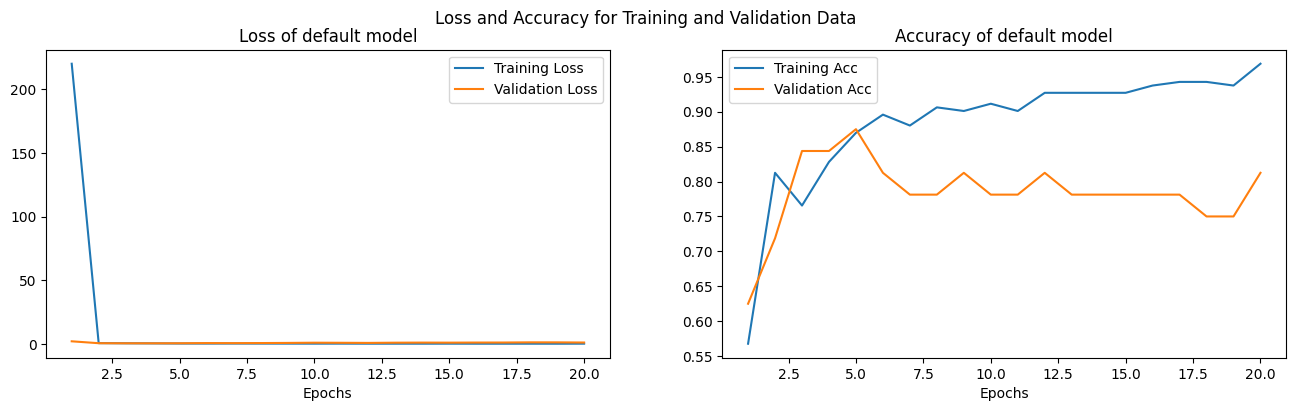

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step - accuracy: 0.9694 - loss: 0.0871
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 636ms/step - accuracy: 0.8125 - loss: 1.0282


[1.0281562805175781, 0.8125]

In [94]:

tf.random.set_seed(1234)
np.random.seed(1234)

# initialize model
model_tf = tf.keras.Sequential()

# add convolutional layer
### YOUR CODE HERE ###
model_tf.add(tf.keras.layers.Conv2D(
    filters=12, kernel_size=4, strides=(1, 1), padding='same',
    data_format='channels_last', activation='relu', name='conv_1'
))

# add max pooling layer
### YOUR CODE HERE ###
model_tf.add(tf.keras.layers.MaxPooling2D(pool_size=2))

# add dropout layer
### YOUR CODE HERE ###
model_tf.add(tf.keras.layers.Dropout(rate=0.3))

# add a flattening layer
### YOUR CODE HERE ###
model_tf.add(tf.keras.layers.Flatten())

# add the classification layer
### YOUR CODE HERE ###
model_tf.add(tf.keras.layers.Dense(
    units=1, activation='sigmoid'
))

# build and compile model
model_tf.build(input_shape=(None, 224, 224, 3))
model_tf.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

# print model_tf summary
### YOUR CODE HERE ###
print(model_tf.summary())

# train model_tf on (X_train, y_train) data
### YOUR CODE HERE ###
model_tf_fit = model_tf.fit(
    x = X_train,
    y = y_train,
    validation_data = [X_val, y_val],
    epochs = 20,
    callbacks=[early_stopping]
)

# plot loss curves
### YOUR CODE HERE ###
hist = model_tf_fit.history
num_epochs = len(hist['accuracy'])

# Plotting the loss on the first subplot
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss of default model');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Accuracy of default model')

# Getting overall title and showing the plot
fig.suptitle('Loss and Accuracy for Training and Validation Data')
plt.show()

# evaluate the accuracy of model_tf on (X_train, y_train) and (X_val, y_val)
### YOUR CODE HERE ###
model_tf.evaluate(X_train, y_train)
model_tf.evaluate(X_val, y_val)

How many parameters does *model_tf* have? The model_tf has 151,117 trainable parameters. For the first layer, we have 12 4x4 kernels with 3 color channels plus a bias, giving us (4 x 4 x 3 + 1) * 12 = 588 parameters in the convolution layer. In the flattening layer, we flatten the 112x112x12 (12 feature maps of 112 x 112 pixels) into a sequence of length 112 x 112 x 12 = 150,528, and after adding a bias term, we get a final dense layer of 150,529 parameters. Adding those two values together gets us 151,117 parameters total.

Comment on *model_tf* accuracy on training vs. validation data: While the training accuracy seemed to improve a bit over time, the validation accuracy rose quickly in the beginning, but then dropped off and plateaued relatively quickly. The losses showed a similar story, where the training loss decreased pretty consistently for the most part, whereas the validation loss had an initial decrease, and then rose back up.

Overall, I would say this model probably doesn't do a great job generalizing, as the validation accuracy didn't improve very much after the first few epochs (and the increasing validation loss indicates a degree of overfitting with this model). In fact, the final validation accuracy is around 0.15 below the training accuracy, further suggesting that generalization is not great.

#### <span style="color:chocolate"> Exercise 6 (20 points) </span>

1. Fine-tune the number of hidden layers and the hyperparameters of *model_tf* to determine the setup that yields the most optimal generalization performance. Feel free to explore various model configurations/hyperparameter values.

2. How many parameters does your fine-tuned model have?

3. Evaluate the accuracy of the fine-tuned model on (X_train, y_train) and (X_val, y_val) data. Comment on model performance on training vs. validation datasets.  Is there an improvement compared to the non-fine-tuned version of the model (Exercise 5)?

In [110]:
### YOUR CODE HERE ###
tf.random.set_seed(1234)
np.random.seed(1234)

# Initializing the model
model_tuned = tf.keras.Sequential()

# Adding layers
model_tuned.add(tf.keras.layers.Conv2D(
    filters=16, kernel_size=5, strides=(1, 1), padding='same',
    data_format='channels_last', activation='relu', name='conv_1'
))
model_tuned.add(tf.keras.layers.MaxPooling2D(pool_size=2, name='max_pooling_1'))
model_tuned.add(tf.keras.layers.Dropout(rate=0.3, name='dropout_1'))
model_tuned.add(tf.keras.layers.Conv2D(
    filters=16, kernel_size=3, strides=(1, 1), padding='same',
    data_format='channels_last', activation='relu', name='conv_2'
))
model_tuned.add(tf.keras.layers.MaxPooling2D(pool_size=2, name='max_pooling_2'))
model_tuned.add(tf.keras.layers.Dropout(rate=0.3, name='dropout_2'))
model_tuned.add(tf.keras.layers.Flatten(name='flatten'))
model_tuned.add(tf.keras.layers.Dense(
    units=1, activation='sigmoid', name='output'
))

# Build and compiling model
model_tuned.build(input_shape=(None, 224, 224, 3))
model_tuned.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

# Printing model_tuned summary
print(model_tuned.summary())

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                      │ (None, 224, 224, 16)        │           1,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling_1 (MaxPooling2D)         │ (None, 112, 112, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 112, 112, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_2 (Conv2D)                      │ (None, 112, 112, 16)        │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling_2 (MaxPooling2D)         │ (None, 56, 56, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 56, 56, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │          50,177 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,713 (209.82 KB)

 Trainable params: 53,713 (209.82 KB)

 Non-trainable params: 0 (0.00 B)

None


Changes made to the model:
 - Added another convolution, max pooling, and dropout layer
 - Changed the first convolution filter to a 5x5 kernel and the second convolution filter to a 3x3 kernel
 - Increased the number of filters in both convolution layers to 16
 - Decreased the number of epochs to 10 (to avoid overfitting)

In [111]:
# Training model_tuned on (X_train, y_train) data
model_tuned_fit = model_tuned.fit(
    x = X_train,
    y = y_train,
    validation_data = [X_val, y_val],
    epochs = 10,
    batch_size = 16,
    callbacks=[early_stopping]
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 867ms/step - accuracy: 0.5153 - loss: 1.0143 - val_accuracy: 0.9062 - val_loss: 0.6315
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.7403 - loss: 0.5801 - val_accuracy: 0.8750 - val_loss: 0.4456
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 986ms/step - accuracy: 0.8246 - loss: 0.3988 - val_accuracy: 0.8750 - val_loss: 0.3072
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.8339 - loss: 0.2833 - val_accuracy: 0.8750 - val_loss: 0.3135
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 947ms/step - accuracy: 0.8433 - loss: 0.2838 - val_accuracy: 0.7500 - val_loss: 0.4376
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9065 - loss: 0.1998 - val_accuracy: 0.8125 - val_loss: 0.4316
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 866ms/step - accuracy: 0.9168 - loss: 0.1913 - val_accuracy: 0.8438 - val_loss: 0.3941
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 984ms/step - accuracy: 0.9125 - loss: 0.1878 - val_accuracy: 0.8

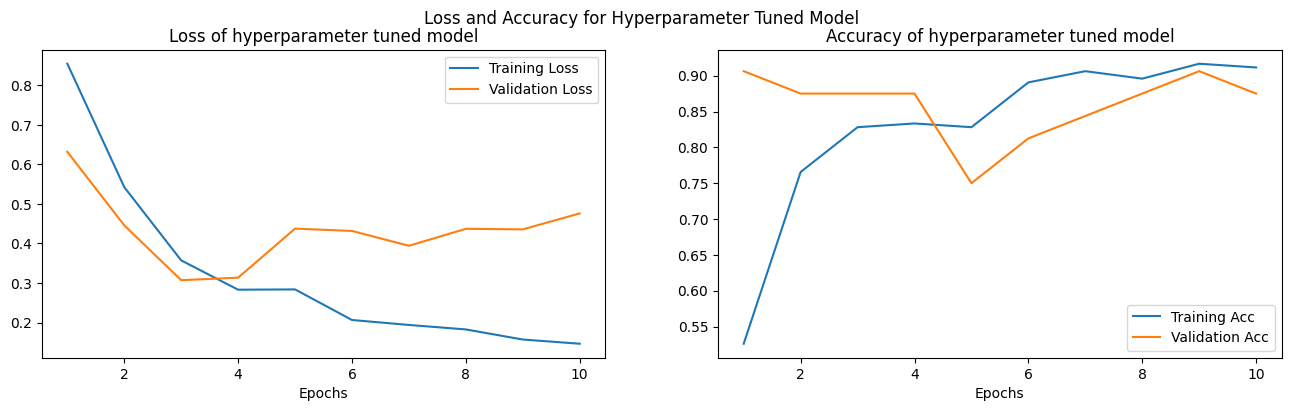

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 431ms/step - accuracy: 0.9519 - loss: 0.1260
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.9062 - loss: 0.4356


[0.43560728430747986, 0.90625]

In [115]:
# Getting history and appropriate number of epochs
hist_tuned = model_tuned_fit.history
num_epochs = len(hist_tuned['accuracy'])

# Plotting the loss on the first subplot
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_tuned['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_tuned['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss of hyperparameter tuned model');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_tuned['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_tuned['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Accuracy of hyperparameter tuned model')

# Getting overall title and showing the plot
fig.suptitle('Loss and Accuracy for Hyperparameter Tuned Model')
plt.show()

# Evaluating the accuracy of model_tuned on (X_train, y_train) and (X_val, y_val)
model_tuned.evaluate(X_train, y_train)
model_tuned.evaluate(X_val, y_val)

In [114]:
# Comparing accuracies of non-fine-tuned vs fine-tuned model
print("Non-fine-tuned model training accuracy:",
      model_tf.evaluate(X_train, y_train, verbose=0)[1])
print("Non-fine-tuned model validation accuracy:",
      model_tf.evaluate(X_val, y_val, verbose=0)[1])
print("Fine-tuned model training accuracy:",
      model_tuned.evaluate(X_train, y_train, verbose=0)[1])
print("Fine-tuned model validation accuracy:",
      model_tuned.evaluate(X_val, y_val, verbose=0)[1])

Non-fine-tuned model training accuracy: 0.953125
Non-fine-tuned model validation accuracy: 0.8125
Fine-tuned model training accuracy: 0.9322916865348816
Fine-tuned model validation accuracy: 0.90625


How many parameters does your fine-tuned model have?

The fine-tuned model_tuned has 53,713 trainable parameters. For the first convolution layer, we have 16 5x5 kernels with 3 color channels plus a bias, giving us (5 x 5 x 3 + 1) x 16 = 1,216 parameters in this convolution layer. After doing a max pooling layer to get our image to 112x112 pixels, we added another convolution layer. This time, we have 16 3x3 kernels with the 16 feature maps from the previous convolution, giving us (3 x 3 x 16 + 1) x 16 = 2,320 parameters in the second convolution layer. In the flattening layer, we flatten the 56x56x16 (16 feature maps of 56 x 56 pixels) into a sequence of length 56 x 56 x 16 = 50,176, and after adding a bias term, we get a final dense layer of 50,177 parameters. Adding all those values together gets us 53,713 parameters total.

Comment on accuracy of the fine-tuned model on training vs. validation performance. Is there an improvement over the non-fine-tuned version?

The training and validation accuracy graphs for the fine-tuned model have some resemblance to those of the default, non-fine-tuned model. Basically, while the training accuracy seemed to improve a bit over time, with lower losses at each stage, the validation accuracy just could not seem to get past that 0.90 mark, with fluctuating losses as well.

One likely explanation for the validation accuracies is that there simply isn't that much validation data to use (32 examples). Therefore, it's difficult to get huge improvements unless the model nearly perfectly identifies all examples.

Thus, even though the model seems to indicate decent generalization performance (with a validation accuracy only ~0.03 lower than the training accuracy), I would be cautious in saying that this model is definitively good at recognizing the two classes until we see the test data evaluation.

When comparing to the non-fine-tuned model, while the training accuracy ended up bit worse, the validation accuracy was much better. This is likely due to the decision only train for 10 epochs, as more training seemed to cause the model to overfit. Once again, we see that the fine-tuned model has better generalization capabilities, but we'll need to compare it with the test data to confirm.

---
### Step 6: Evaluation

#### <span style="color:chocolate"> Exercise 7 (10 points) </span>

You will now use the test data to evaluate the performance (accuracy) of your fine-tuned model on unseen data. Does your model generalize well?

In [119]:
### YOUR CODE HERE ###

# Checking generalization performance of the fine-tuned model using test data
print("Fine-tuned model test accuracy:",
      model_tuned.evaluate(X_test, y_test, verbose=0)[1])

Fine-tuned model test accuracy: 0.75


Does your model generalize well? This model clearly does not generalize well at all. Even though it achieved a validation accuracy of 0.9, it only achieved a test accuracy 0.75, potentially indicating that the test data is significantly different from the validation data. This, however, again comes with the caveat that we only had 32 images in the test dataset, so it's extremely likely that the validation and test images are simply too different.

Overall, this does confirm that the model does not generalize well, and some improvements should try to be made to the model before deployment, likely by trying to increase the filter amounts, adding more convolution layers, and decreasing the learning rate while increasing the number of epochs.

In [125]:
# Below is some additional testing with significantly more filters to see how
# well the model performs:

In [122]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Initializing the model
model_tuned_2 = tf.keras.Sequential()

# Adding layers
model_tuned_2.add(tf.keras.layers.Conv2D(
    filters=128, kernel_size=7, strides=(1, 1), padding='same',
    data_format='channels_last', activation='relu', name='conv_1'))
model_tuned_2.add(tf.keras.layers.MaxPooling2D(pool_size=2, name='max_pooling_1'))
model_tuned_2.add(tf.keras.layers.Dropout(rate=0.3, name='dropout_1'))

model_tuned_2.add(tf.keras.layers.Conv2D(
    filters=64, kernel_size=5, strides=(1, 1), padding='same',
    data_format='channels_last', activation='relu', name='conv_2'))
model_tuned_2.add(tf.keras.layers.MaxPooling2D(pool_size=2, name='max_pooling_2'))
model_tuned_2.add(tf.keras.layers.Dropout(rate=0.3, name='dropout_2'))

model_tuned_2.add(tf.keras.layers.Conv2D(
    filters=32, kernel_size=3, strides=(1, 1), padding='same',
    data_format='channels_last', activation='relu', name='conv_3'))
model_tuned_2.add(tf.keras.layers.MaxPooling2D(pool_size=2, name='max_pooling_3'))
model_tuned_2.add(tf.keras.layers.Dropout(rate=0.3, name='dropout_3'))

# Flattening and output layers
model_tuned_2.add(tf.keras.layers.Flatten(name='flatten'))
model_tuned_2.add(tf.keras.layers.Dense(
    units=1, activation='sigmoid', name='output'
))

# Build and compiling model
model_tuned_2.build(input_shape=(None, 224, 224, 3))
model_tuned_2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

# Printing model_tuned_2 summary
print(model_tuned_2.summary())

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                      │ (None, 224, 224, 128)       │          18,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling_1 (MaxPooling2D)         │ (None, 112, 112, 128)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 112, 112, 128)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_2 (Conv2D)                      │ (None, 112, 112, 64)        │         204,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling_2 (MaxPooling2D)         │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_3 (Conv2D)                      │ (None, 56, 56, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling_3 (MaxPooling2D)         │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │          25,089 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 267,361 (1.02 MB)

 Trainable params: 267,361 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

None


In [123]:
# Training model_tuned_2 on (X_train, y_train) data
model_tuned_2_fit = model_tuned_2.fit(
    x = X_train,
    y = y_train,
    validation_data = [X_val, y_val],
    epochs = 20,
    batch_size = 16,
    callbacks=[early_stopping]
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 140s 11s/step - accuracy: 0.4194 - loss: 0.7912 - val_accuracy: 0.5625 - val_loss: 0.6696
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 138s 11s/step - accuracy: 0.5310 - loss: 0.6463 - val_accuracy: 0.7812 - val_loss: 0.4763
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 141s 12s/step - accuracy: 0.8044 - loss: 0.3874 - val_accuracy: 0.8750 - val_loss: 0.2966
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 134s 11s/step - accuracy: 0.8798 - loss: 0.4846 - val_accuracy: 0.8125 - val_loss: 0.3664
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 146s 12s/step - accuracy: 0.8446 - loss: 0.3413 - val_accuracy: 0.7812 - val_loss: 0.3724
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 138s 11s/step - accuracy: 0.8738 - loss: 0.2709 - val_accuracy: 0.8750 - val_loss: 0.3450
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 139s 12s/step - accuracy: 0.8655 - loss: 0.2709 - val_accuracy: 0.8750 - val_loss: 0.3421
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 138s 11s/step - accuracy: 0.8646 - loss: 0.2675 - val_accuracy: 0.

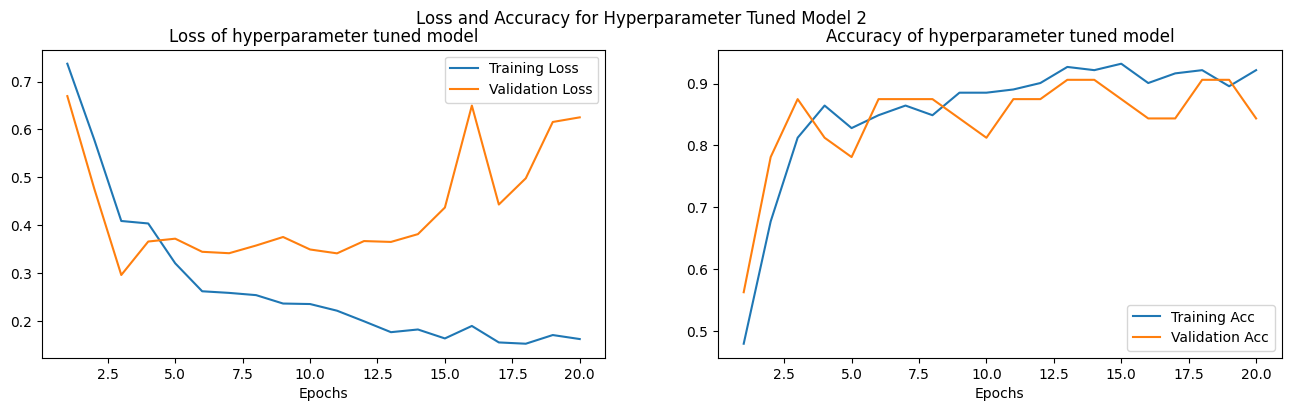

6/6 ━━━━━━━━━━━━━━━━━━━━ 36s 6s/step - accuracy: 0.9281 - loss: 0.1586
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.8750 - loss: 0.4373


[0.43730032444000244, 0.875]

In [128]:
# Getting history and appropriate number of epochs
hist_tuned_2 = model_tuned_2_fit.history
num_epochs_2 = len(hist_tuned_2['accuracy'])

# Plotting the loss on the first subplot
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs_2+1), hist_tuned_2['loss'], label='Training Loss')
plt.plot(range(1, num_epochs_2+1), hist_tuned_2['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss of hyperparameter tuned model');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs_2+1), hist_tuned_2['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs_2+1), hist_tuned_2['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Accuracy of hyperparameter tuned model')

# Getting overall title and showing the plot
fig.suptitle('Loss and Accuracy for Hyperparameter Tuned Model 2')
plt.show()

# Evaluating the accuracy of model_tuned on (X_train, y_train) and (X_val, y_val)
model_tuned_2.evaluate(X_train, y_train)
model_tuned_2.evaluate(X_val, y_val)

In [127]:
# Checking generalization performance of the fine-tuned model using test data
print("Fine-tuned model test accuracy:",
      model_tuned_2.evaluate(X_test, y_test, verbose=0)[1])

Fine-tuned model test accuracy: 0.8125


Overall, we see that even training this model for ~45 minutes, this model still barely does better than our previous one. The training and validation curves are comparable, and the test accuracy is still not that great compared to the validation accuracy. At the very least, the test accuracy for this model is a bit better than its original counterpart, so perhaps this model does have slightly improved generalization capabilities.